In [1]:
import pypsa
import xarray as xr
import linopy as lp
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import beta
from scipy.interpolate import interp1d
from sklearn.metrics import mean_squared_error

In [2]:
# SOC indem die Füllstände des H2 Stores aufsummiert werden und durch die installierte Kapazität geteilt werden

def get_hydrogen_soc(n):
    hydrogen_e = 0
    hydrogen_e_nom = 0

    for year in [2045, 2040, 2035, 2030, 2020]:

        hydrogen_e += n.stores_t.e[f"DE0 0 H2 Store-{year}"]
        hydrogen_e_nom += n.stores.e_nom[f"DE0 0 H2 Store-{year}"]

    soc = hydrogen_e / hydrogen_e_nom

    return soc

- ein Netzwerk mit perfect foresight lösen um mean für hydrogen und methanol stores zu bekommen.

- ich nehme nicht das Netzwerk direkt, weil da sind CO2 Constraints mit drin und deswegen ist der Preis vom hydrogen (weil die Konkurrenz teurer ist, höher)
    - Preis ist bei 90€ anstatt wie 19€ jetzt
    - wenn ich die 90 nehme dann hat man wieder so lange phasen von niedrigen Preisen.

- sollte aber kein Problem sein, weil sobald alle constraints drin sind der Wert ja einfach angepasst werden kann bzw. automatisch aktualisiert wird

In [3]:
n_perfect_forecast = pypsa.Network('base_s_1__none_2045_lt.nc')
n_perfect_forecast.optimize.fix_optimal_capacities()
n_perfect_forecast.optimize.create_model()

n_perfect_forecast.optimize.solve_model(
    solver_name = 'gurobi'
)

INFO:pypsa.io:Imported network base_s_1__none_2045_lt.nc has buses, carriers, generators, global_constraints, links, loads, storage_units, stores
Index(['load-shedding'], dtype='object', name='Generator')
Index(['DE0 0 urban central gas CHP-2010', 'DE0 0 urban central oil CHP-2010',
       'DE0 0 urban central gas CHP-2015', 'DE0 0 urban central oil CHP-2015',
       'DE0 0 urban central gas CHP-2020', 'DE0 0 urban central oil CHP-2020',
       'DE0 0 CCGT-1980', 'DE0 0 CCGT-2010', 'DE0 0 CCGT-2015',
       'DE0 0 CCGT-2020', 'DE0 0 H2 OCGT-2035', 'DE0 0 H2 retrofit OCGT-2030',
       'DE0 0 H2 OCGT-2040', 'DE0 0 H2 OCGT-2045'],
      dtype='object', name='Link')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 8/8 [00:00<00:00, 12.74it/s]
INFO:linopy.io: Writing time: 5.34s


Set parameter Username


INFO:gurobipy:Set parameter Username


Academic license - for non-commercial use only - expires 2025-12-05


INFO:gurobipy:Academic license - for non-commercial use only - expires 2025-12-05


...

Solved in 43339 iterations and 11.64 seconds (8.74 work units)


INFO:gurobipy:Solved in 43339 iterations and 11.64 seconds (8.74 work units)


Optimal objective  1.531699993e+10


INFO:gurobipy:Optimal objective  1.531699993e+10
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 712467 primals, 1442488 duals
Objective: 1.53e+10
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Link-fix-p-lower, Link-fix-p-upper, Store-fix-e-lower, Store-fix-e-upper, StorageUnit-fix-p_dispatch-lower, StorageUnit-fix-p_dispatch-upper, StorageUnit-fix-p_store-lower, StorageUnit-fix-p_store-upper, StorageUnit-fix-state_of_charge-lower, StorageUnit-fix-state_of_charge-upper, StorageUnit-energy_balance, Store-energy_balance were not assigned to the network.


('ok', 'optimal')

- dann netzwerk mit rolling horizon lösen:
    - marginal cost des methanol und hydrogen stores auf mean des perfect foresight netzes legen
    - cyclic aus, weil sonst nicht long term gestored werden kann (damit es einfacher ist einfach für alle)
    - dann optimieren. overlap auf 8, ansonsten gibt preisspitzen weil billigere Strompreise durch PV am nächsten tag nicht abgeschätzt werden können
    - e_initial des h2 speichers auf den wert des perfect-foresight modells setzen

In [4]:
n = pypsa.Network('base_s_1__none_2045_lt.nc')

# alle hydrogen related stores
stores = n.stores[n.stores.carrier.str.contains("H2", case=False, na=False)].index


# marginal price für alle der mean
for i in stores:
    n.stores.loc[i, 'marginal_cost'] = n_perfect_forecast.buses_t.marginal_price['DE0 0 H2'].mean()

# gleiches für den einen methanol store 
n.stores.loc['DE methanol Store', 'marginal_cost'] = n_perfect_forecast.buses_t.marginal_price["DE methanol"].mean()

# bei allen stores wird cyclic auf false gesetzt
for i in n.stores.index:
    n.stores.loc[i, 'e_cyclic'] = False

# initial storage aus perfect foresight
n.stores.loc['DE0 0 H2 Store-2045', 'e_initial'] = 5 * 10e6
n.stores.loc['DE0 0 H2 Store-2040', 'e_initial'] = 5 * 10e5
n.stores.loc['DE0 0 H2 Store-2035', 'e_initial'] = 0
n.stores.loc['DE0 0 H2 Store-2030', 'e_initial'] = 0


# optimierung mit horizon = 48 (144h) und overlap = 8
n.optimize.fix_optimal_capacities()
n.optimize.create_model()

n.optimize.optimize_with_rolling_horizon(
    horizon = 48,
    overlap = 8,
    solver_name = 'gurobi'
)

INFO:pypsa.io:Imported network base_s_1__none_2045_lt.nc has buses, carriers, generators, global_constraints, links, loads, storage_units, stores
Index(['load-shedding'], dtype='object', name='Generator')
Index(['DE0 0 urban central gas CHP-2010', 'DE0 0 urban central oil CHP-2010',
       'DE0 0 urban central gas CHP-2015', 'DE0 0 urban central oil CHP-2015',
       'DE0 0 urban central gas CHP-2020', 'DE0 0 urban central oil CHP-2020',
       'DE0 0 CCGT-1980', 'DE0 0 CCGT-2010', 'DE0 0 CCGT-2015',
       'DE0 0 CCGT-2020', 'DE0 0 H2 OCGT-2035', 'DE0 0 H2 retrofit OCGT-2030',
       'DE0 0 H2 OCGT-2040', 'DE0 0 H2 OCGT-2045'],
      dtype='object', name='Link')
INFO:pypsa.optimization.abstract:Optimizing network for snapshot horizon [2019-01-01 00:00:00:2019-01-06 21:00:00] (1/73).
Index(['load-shedding'], dtype='object', name='Generator')
Index(['DE0 0 urban central gas CHP-2010', 'DE0 0 urban central oil CHP-2010',
       'DE0 0 urban central gas CHP-2015', 'DE0 0 urban central oil

Set parameter Username


INFO:gurobipy:Set parameter Username


Academic license - for non-commercial use only - expires 2025-12-05


INFO:gurobipy:Academic license - for non-commercial use only - expires 2025-12-05


...

Solved in 1083 iterations and 0.04 seconds (0.03 work units)


INFO:gurobipy:Solved in 1083 iterations and 0.04 seconds (0.03 work units)


Optimal objective  3.810967068e+08


INFO:gurobipy:Optimal objective  3.810967068e+08
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 9760 primals, 19768 duals
Objective: 3.81e+08
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Link-fix-p-lower, Link-fix-p-upper, Store-fix-e-lower, Store-fix-e-upper, StorageUnit-fix-p_dispatch-lower, StorageUnit-fix-p_dispatch-upper, StorageUnit-fix-p_store-lower, StorageUnit-fix-p_store-upper, StorageUnit-fix-state_of_charge-lower, StorageUnit-fix-state_of_charge-upper, StorageUnit-energy_balance, Store-energy_balance were not assigned to the network.


Unnamed PyPSA Network
---------------------
Components:
 - Bus: 47
 - Carrier: 97
 - Generator: 41
 - GlobalConstraint: 12
 - Link: 118
 - Load: 23
 - StorageUnit: 2
 - Store: 39
Snapshots: 2920

# Strompreise, SOC und marginal price von H2

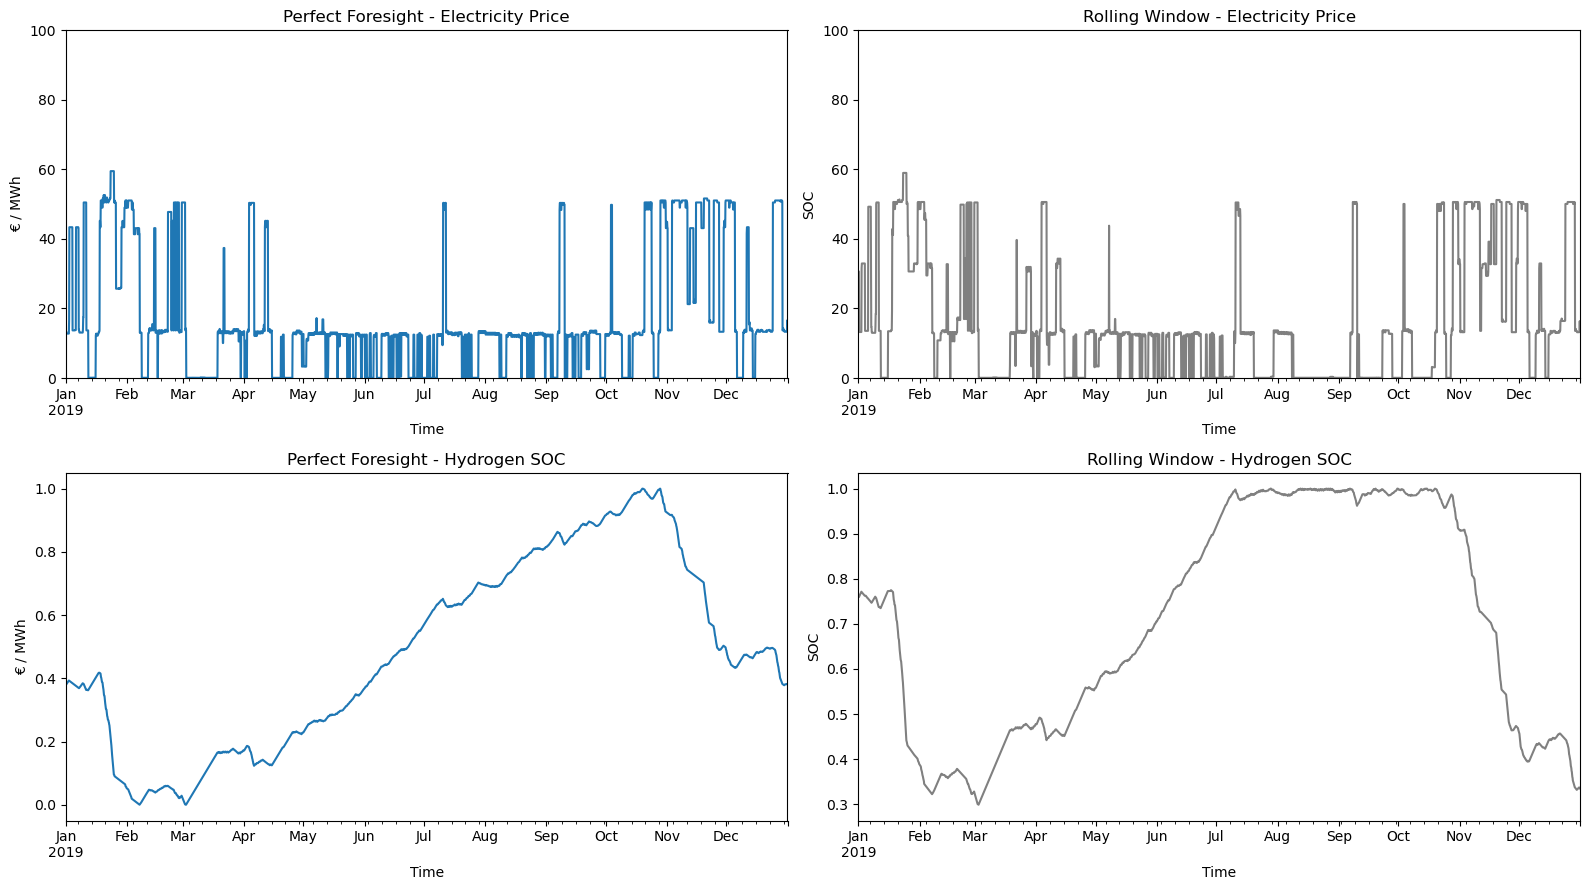

In [5]:
fig, ax = plt.subplots(2,2, figsize=(16,9))

n_perfect_forecast.buses_t.marginal_price['DE0 0'].plot(
    ax = ax[0][0],
    ylim=(0, 100),
    title = 'Perfect Foresight - Electricity Price'
)

n.buses_t.marginal_price['DE0 0'].plot(
    ax = ax[0][1],
    ylim = (0, 100),
    title = 'Rolling Window - Electricity Price',
    color = 'grey'
)

get_hydrogen_soc(n_perfect_forecast).plot(
    ax = ax[1][0],
    title = 'Perfect Foresight - Hydrogen SOC'
)
get_hydrogen_soc(n).plot(
    ax = ax[1][1],
    title = 'Rolling Window - Hydrogen SOC',
    color = 'grey'

)

ax[0][0].set_xlabel("Time")
ax[1][0].set_xlabel("Time")
ax[0][1].set_xlabel("Time")
ax[1][1].set_xlabel("Time")

ax[0][0].set_ylabel("€ / MWh")
ax[1][0].set_ylabel("€ / MWh")
ax[0][1].set_ylabel("SOC")
ax[1][1].set_ylabel("SOC")

plt.tight_layout()


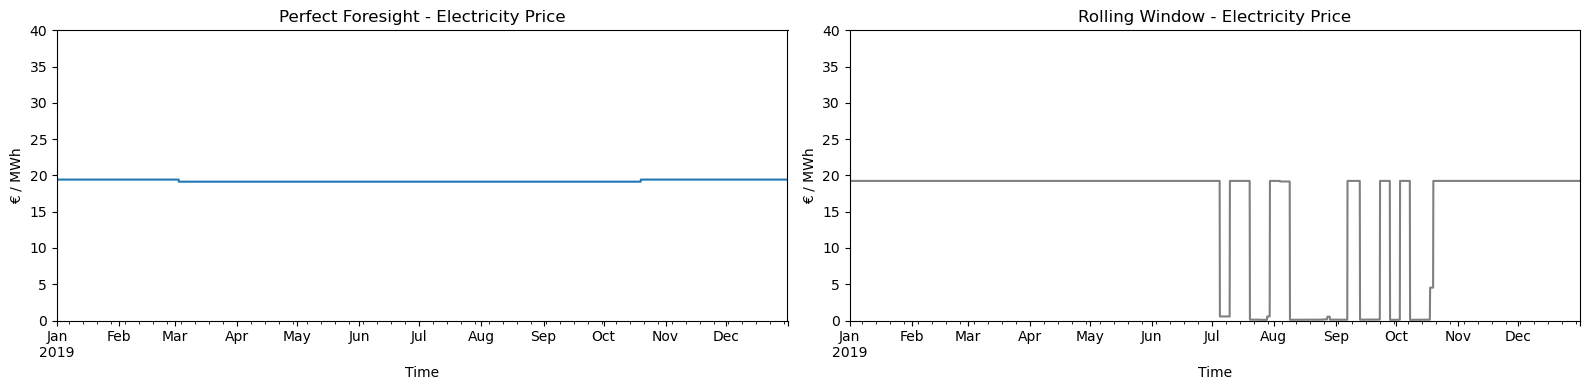

In [6]:
fig, ax = plt.subplots(1,2, figsize=(16,4))

n_perfect_forecast.buses_t.marginal_price['DE0 0 H2'].plot(
    ax = ax[0],
    ylim=(0, 40),
    title = 'Perfect Foresight - Electricity Price'
)

n.buses_t.marginal_price['DE0 0 H2'].plot(
    ax = ax[1],
    ylim = (0, 40),
    title = 'Rolling Window - Electricity Price',
    color = 'grey'
)

ax[0].set_xlabel('Time')
ax[1].set_xlabel('Time')
ax[0].set_ylabel('€ / MWh')
ax[1].set_ylabel('€ / MWh')

plt.tight_layout()

Problematisch:

- Hydrogen muss am anfang und am Ende nicht gleich sein.
- Preise nahe null im september kommen vom hydrogen:
    - marginal price von hydrogen da ist 0 --> anreiz hydrogen los zu werden.

Lösungansätze:
- einen zusätzlichen hydrogen verbrauch einfügen der den speicher im Sommer künstlich entleert um den Anfangszustand zu kompensieren
- also den Strompreis nicht beeinflusst sondern einfach vom Hydrogen Bus Hydrogen entnimmt

# Erzeugung:

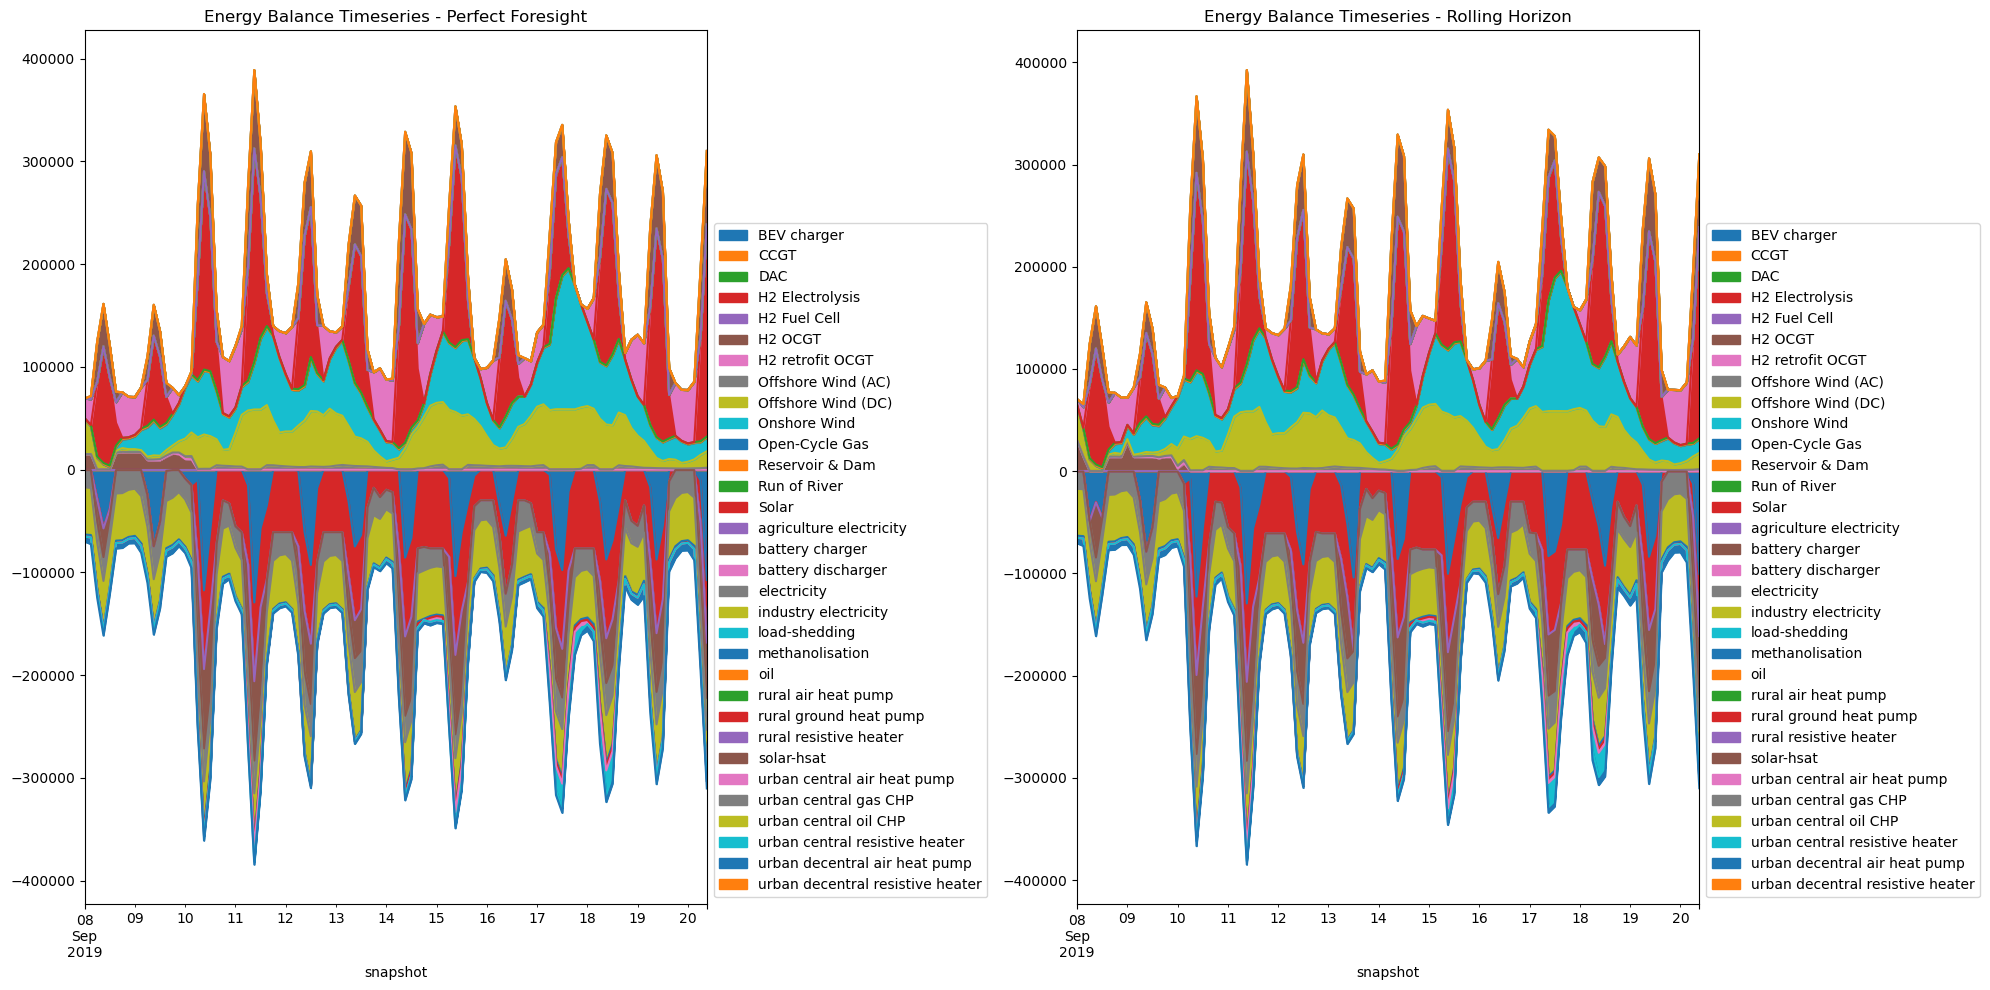

In [15]:
fig, ax = plt.subplots(1,2,figsize=(20,10))

n_lt.statistics.energy_balance(aggregate_time=False).loc[:, :, "AC"].droplevel(0).iloc[
    :, 2000:2100
].groupby("carrier").sum().where(lambda x: np.abs(x) > 1).fillna(0).drop("Pumped Hydro Storage", axis=0, errors="ignore").T.plot.area(
    ax = ax[0],
    title="Energy Balance Timeseries - Perfect Foresight"
)
ax[0].legend(bbox_to_anchor=(1, 0), loc="lower left", title=None, ncol=1)
plt.tight_layout()

n_perfect_forecast.statistics.energy_balance(aggregate_time=False).loc[:, :, "AC"].droplevel(0).iloc[
    :, 2000:2100
].groupby("carrier").sum().where(lambda x: np.abs(x) > 1).fillna(0).drop("Pumped Hydro Storage", axis=0, errors="ignore").T.plot.area(
    ax = ax[1],
    title="Energy Balance Timeseries - Rolling Horizon"
)
ax[1].legend(bbox_to_anchor=(1, 0), loc="lower left", title=None, ncol=1)
plt.tight_layout()

- Energy Balance sieht auch ähnlich aus
- mehr pink im august kommt wie gesagt von dem hydrogen storage. 
- mehr Wärme liegt an der geringeren Planungsfähigkeit, beeinflusst den Strompreis allerdings nicht also who cares

In [ ]:
def plot_balance(nb, tech_colors=None):
    
    resample="D"
    nb = nb.resample(resample).mean()

    df = nb

    # split into df with positive and negative values
    df_neg, df_pos = df.clip(upper=0), df.clip(lower=0)
    df_pos = df_pos[df_pos.sum().sort_values(ascending=False).index]
    df_neg = df_neg[df_neg.sum().sort_values().index]
    # get colors
    c_neg = [tech_colors[col] if col in tech_colors else "grey" for col in df_neg.columns]
    c_pos = [tech_colors[col] if col in tech_colors else "grey" for col in df_pos.columns]


    fig, ax = plt.subplots(figsize=(14, 8))

    # plot positive values
    ax = df_pos.plot.area(ax=ax, stacked=True, color=c_pos, linewidth=0.0)

    # rename negative values that are also present on positive side, so that they are not shown and plot negative values
    def f(c):
        return "out_" + c

    cols = [f(c) if (c in df_pos.columns) else c for c in df_neg.columns]
    cols_map = dict(zip(df_neg.columns, cols))
    ax = df_neg.rename(columns=cols_map).plot.area(
        ax=ax, stacked=True, color=c_neg, linewidth=0.0
    )

    # explicitly filter out duplicate labels
    handles, labels = ax.get_legend_handles_labels()
    filtered_handles_labels = [
        (h, l) for h, l in zip(handles, labels) if not l.startswith("out_")
    ]
    handles, labels = zip(*filtered_handles_labels)

    # rescale the y-axis
    ax.set_ylim([1.05 * df_neg.sum(axis=1).min(), 1.05 * df_pos.sum(axis=1).max()])
    ax.legend(
        handles,
        labels,
        ncol=1,
        loc="upper center",
        bbox_to_anchor=(1.13, 1.01),
    )
    ax.grid(True)



In [13]:
n_lt = pypsa.Network('base_s_1__none_2045_lt.nc')
from utils import tech_colors

INFO:pypsa.io:Imported network base_s_1__none_2045_lt.nc has buses, carriers, generators, global_constraints, links, loads, storage_units, stores


LT


/home/julian-geis/mambaforge/envs/p-de-25-04/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:1800: UserWarning:

Attempting to set identical low and high ylims makes transformation singular; automatically expanding.



Perfect Forecast


/home/julian-geis/mambaforge/envs/p-de-25-04/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:1800: UserWarning:

Attempting to set identical low and high ylims makes transformation singular; automatically expanding.



Rolling Horizon


/home/julian-geis/mambaforge/envs/p-de-25-04/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:1800: UserWarning:

Attempting to set identical low and high ylims makes transformation singular; automatically expanding.



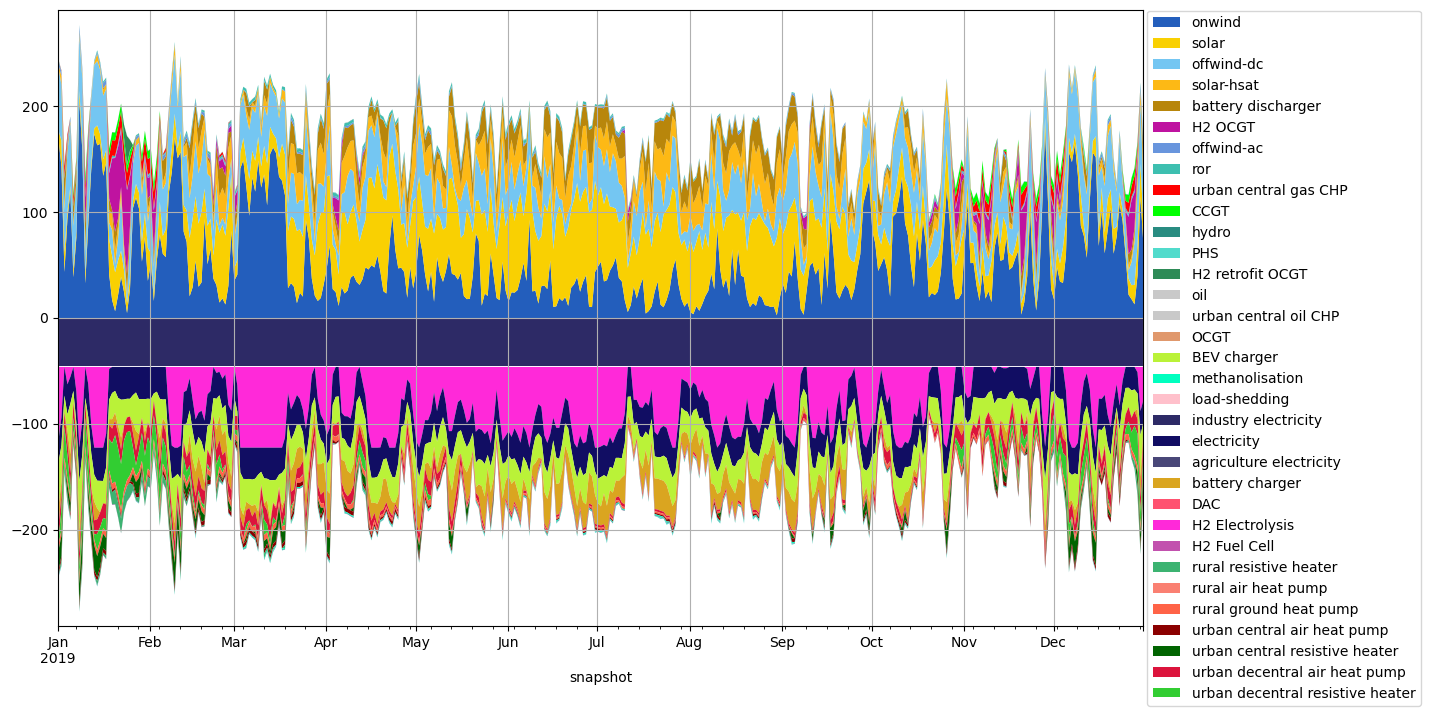

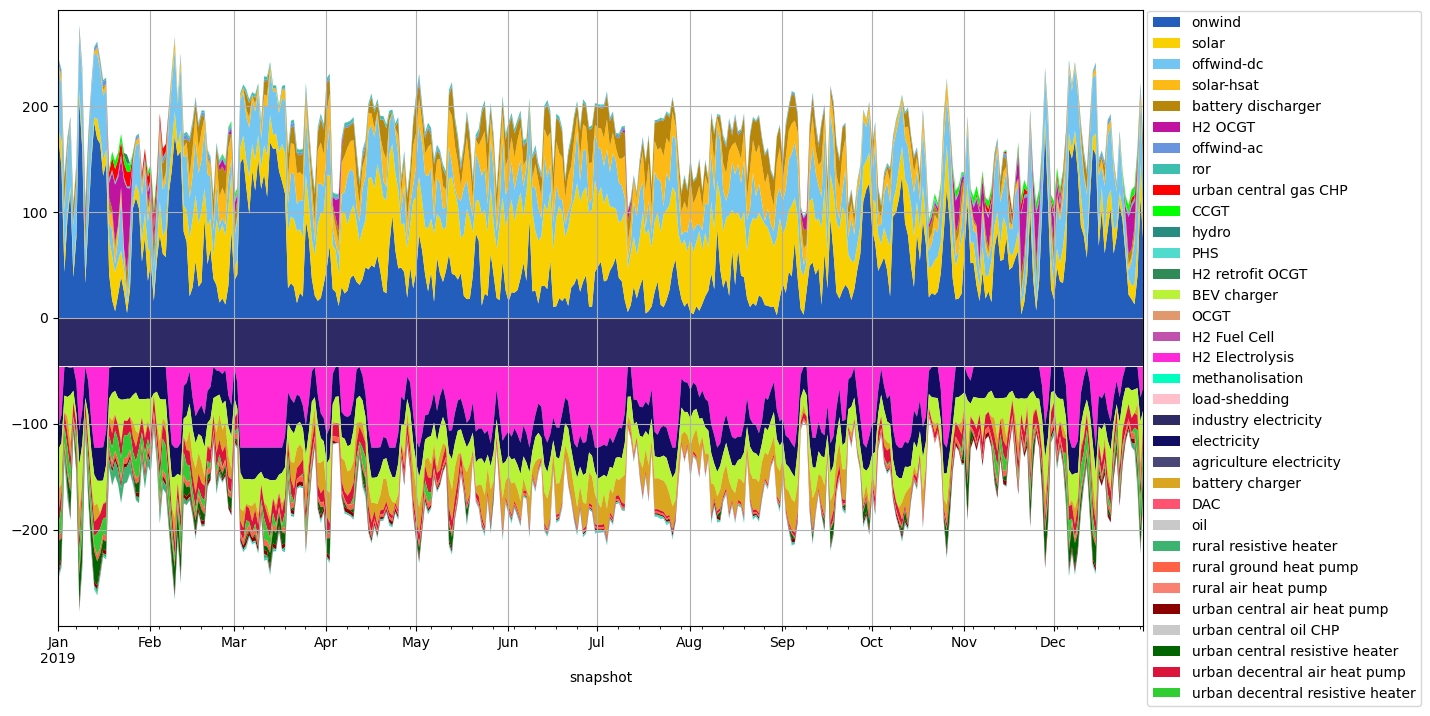

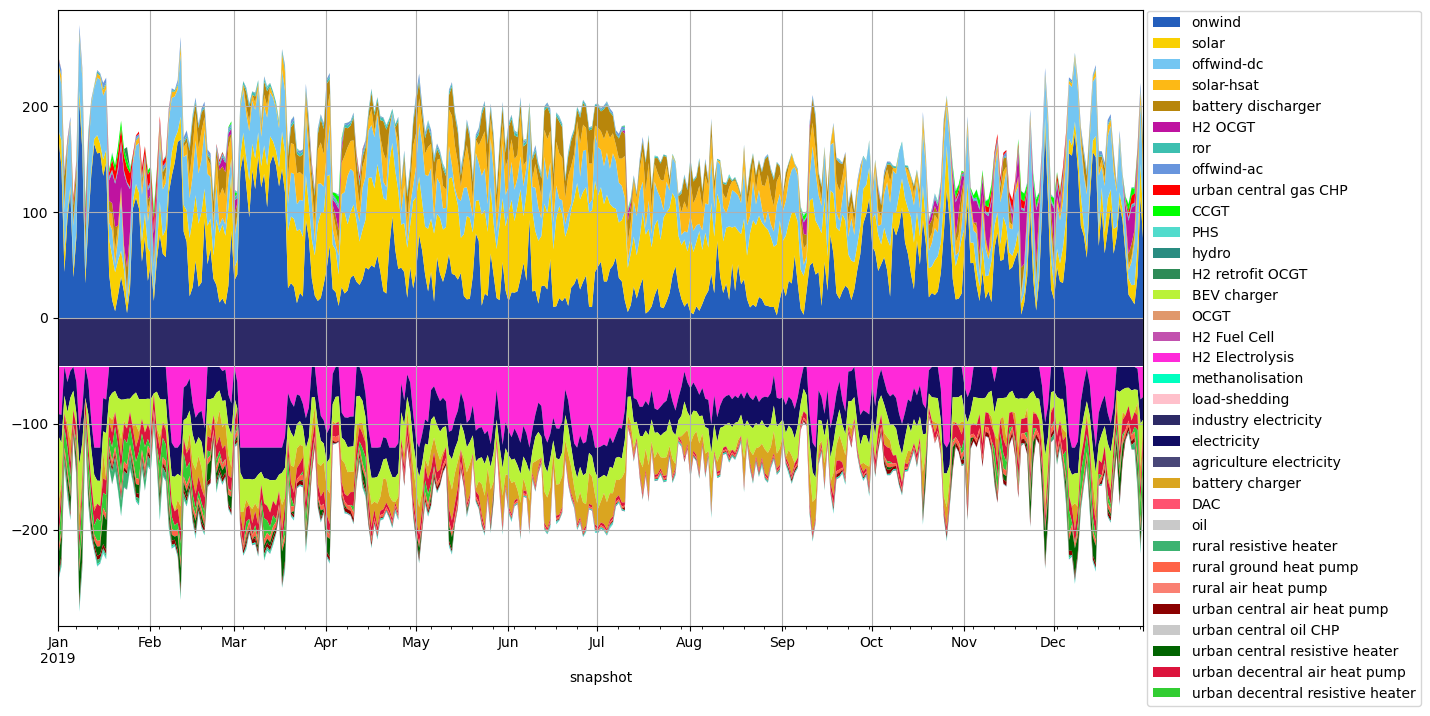

In [14]:
for n, name in zip([n_lt, n_perfect_forecast, n], ["LT", "Perfect Forecast", "Rolling Horizon"]):
    balance = (
        n.statistics.energy_balance(
            aggregate_time=False,
            nice_names=False,
            groupby=["bus", "carrier", "bus_carrier"],
        )
        .droplevel("bus")
    )

    carriers = ["AC"]
    mask = balance.index.get_level_values("bus_carrier").isin(carriers)
    nb = balance[mask].groupby("carrier").sum().div(1e3).T

    print(name)
    fig = plot_balance(nb, tech_colors)

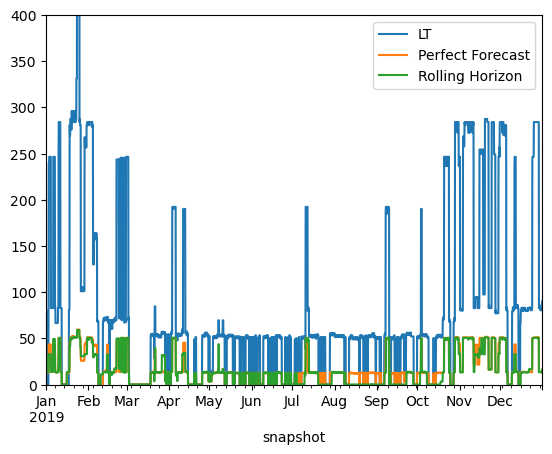

In [18]:
n_lt.buses_t.marginal_price['DE0 0'].plot(label='LT')
n_perfect_forecast.buses_t.marginal_price['DE0 0'].plot(label='Perfect Forecast')
n.buses_t.marginal_price['DE0 0'].plot(label='Rolling Horizon')
plt.ylim(0, 400)
plt.legend()

# Wind Noise:

In [8]:
# Wrapper Funktion um cf übergeben zu können
def change_wind_noise():
    # eigentliche funktion zum ändern der Constraints
    def change_wind(n, sns):
        rhs = n.model.constraints["Generator-fix-p-upper"].rhs
        years = [2045, 2040, 2035, 2030, 2025, 2020]

        for year in years:
            selector = {"Generator-fix": f"DE0 0 onwind-{year}"}
            scaling_factor = np.std(rhs.sel(selector).data)
            p_nom = n.generators.p_nom[f"DE0 0 onwind-{year}"]
            wind_power = rhs.sel(selector) + wind_noise(len(sns), scaling_factor)
            wind_power = wind_power.where(wind_power >= 0, 0)
            wind_power = wind_power.where(wind_power <= p_nom, p_nom)
            rhs.loc[selector] = wind_power

    return change_wind

def wind_noise(hours, scaling_factor):

    # 2. MSE-Werte für LSTM-Modell aus Tabelle bis 168h --> aus der Tabelle des Papers (0 von mir)
    horizons = np.array([0, 24, 48, 72, 96, 168, 336])
    mse_values = np.array([0, 0.499, 0.794, 0.899, 0.943, 1.011, 1.064])
    rmse_std = np.sqrt(mse_values)  # RMSE in Standardform

    # 3. Skaliere RMSE auf echte MW-Einheit
    rmse_MW = rmse_std * scaling_factor

    # 4. Interpolation der RMSE auf 144h
    interp_rmse = interp1d(horizons, rmse_MW, kind='linear', fill_value='extrapolate')
    rmse_per_hour = interp_rmse(np.arange(0, hours*3, 3))  # Stunden 1–144


    # 5. Rauschen generieren und synthetische Prognose erzeugen
    noise = np.random.normal(loc=0, scale=1.2*rmse_per_hour)
    #noise = np.clip(noise, 0, None)  # alles < 0 → 0, Rest bleibt
    return noise


- gleiches Netzwerk erstellen wie oben, aber was mit Windnoise optimiert wird

In [9]:
n_wind_noise = pypsa.Network('base_s_1__none_2045_lt.nc')

# alle hydrogen related stores
stores = n_wind_noise.stores[n_wind_noise.stores.carrier.str.contains("H2", case=False, na=False)].index


# marginal price für alle der mean
for i in stores:
    n_wind_noise.stores.loc[i, 'marginal_cost'] = n_perfect_forecast.buses_t.marginal_price['DE0 0 H2'].mean()

# gleiches für den einen methanol store 
n_wind_noise.stores.loc['DE methanol Store', 'marginal_cost'] = n_perfect_forecast.buses_t.marginal_price["DE methanol"].mean()

# bei allen stores wird cyclic auf false gesetzt
for i in n_wind_noise.stores.index:
    n_wind_noise.stores.loc[i, 'e_cyclic'] = False

# initial storage aus perfect foresight
n_wind_noise.stores.loc['DE0 0 H2 Store-2045', 'e_initial'] = 5 * 10e6
n_wind_noise.stores.loc['DE0 0 H2 Store-2040', 'e_initial'] = 5 * 10e5


# optimierung mit horizon = 48 (144h) und overlap = 8
n_wind_noise.optimize.fix_optimal_capacities()
n_wind_noise.optimize.create_model()

n_wind_noise.optimize.optimize_with_rolling_horizon(
    horizon = 48,
    overlap = 8,
    solver_name = 'gurobi',
    extra_functionality=change_wind_noise()

)

INFO:pypsa.io:Imported network base_s_1__none_2045_lt.nc has buses, carriers, generators, global_constraints, links, loads, storage_units, stores
Index(['load-shedding'], dtype='object', name='Generator')
Index(['DE0 0 urban central gas CHP-2010', 'DE0 0 urban central oil CHP-2010',
       'DE0 0 urban central gas CHP-2015', 'DE0 0 urban central oil CHP-2015',
       'DE0 0 urban central gas CHP-2020', 'DE0 0 urban central oil CHP-2020',
       'DE0 0 CCGT-1980', 'DE0 0 CCGT-2010', 'DE0 0 CCGT-2015',
       'DE0 0 CCGT-2020', 'DE0 0 H2 OCGT-2035', 'DE0 0 H2 retrofit OCGT-2030',
       'DE0 0 H2 OCGT-2040', 'DE0 0 H2 OCGT-2045'],
      dtype='object', name='Link')
INFO:pypsa.optimization.abstract:Optimizing network for snapshot horizon [2019-01-01 00:00:00:2019-01-06 21:00:00] (1/73).
Index(['load-shedding'], dtype='object', name='Generator')
Index(['DE0 0 urban central gas CHP-2010', 'DE0 0 urban central oil CHP-2010',
       'DE0 0 urban central gas CHP-2015', 'DE0 0 urban central oil

Set parameter Username


INFO:gurobipy:Set parameter Username


Academic license - for non-commercial use only - expires 2025-12-05


INFO:gurobipy:Academic license - for non-commercial use only - expires 2025-12-05


...

Solved in 1171 iterations and 0.04 seconds (0.03 work units)


INFO:gurobipy:Solved in 1171 iterations and 0.04 seconds (0.03 work units)


Optimal objective  3.683541859e+08


INFO:gurobipy:Optimal objective  3.683541859e+08
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 9760 primals, 19768 duals
Objective: 3.68e+08
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Link-fix-p-lower, Link-fix-p-upper, Store-fix-e-lower, Store-fix-e-upper, StorageUnit-fix-p_dispatch-lower, StorageUnit-fix-p_dispatch-upper, StorageUnit-fix-p_store-lower, StorageUnit-fix-p_store-upper, StorageUnit-fix-state_of_charge-lower, StorageUnit-fix-state_of_charge-upper, StorageUnit-energy_balance, Store-energy_balance were not assigned to the network.


Unnamed PyPSA Network
---------------------
Components:
 - Bus: 47
 - Carrier: 97
 - Generator: 41
 - GlobalConstraint: 12
 - Link: 118
 - Load: 23
 - StorageUnit: 2
 - Store: 39
Snapshots: 2920

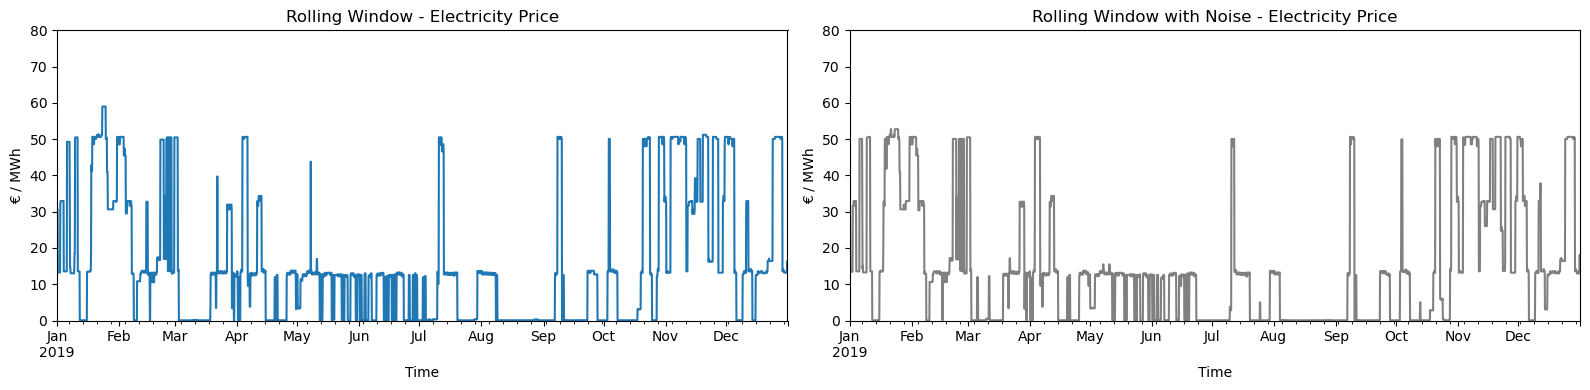

15.583196754740817
14.496422022117667


In [10]:
fig, ax = plt.subplots(1,2, figsize=(16,4))

n.buses_t.marginal_price['DE0 0'].plot(
    ax = ax[0],
    ylim=(0, 80),
    title = 'Rolling Window - Electricity Price'
)

n_wind_noise.buses_t.marginal_price['DE0 0'].plot(
    ax = ax[1],
    ylim = (0, 80),
    title = 'Rolling Window with Noise - Electricity Price',
    color = 'grey'
)

ax[0].set_xlabel('Time')
ax[1].set_xlabel('Time')
ax[0].set_ylabel('€ / MWh')
ax[1].set_ylabel('€ / MWh')

plt.tight_layout()
plt.show()

print(n.buses_t.marginal_price['DE0 0 H2'].mean())
print(n_wind_noise.buses_t.marginal_price['DE0 0 H2'].mean())

- fast gar kein Unterschied.
- allerdings ist der unterschied im Wind-Dispatch auch nur minimal (2%)
- das macht auf das gesamte Stromnetz durch die riesen verfügbarkeit an Kapazitäten und flexibilität fast gar keinen unterschied

- obwohl es natürlich auch an der nicht vorhandenen korrelation liegt. weil gerade bei wind, wenn mal 2h nichts weht und dann für 2h mehr, das ist ja kein problem. wenn jetzt aber korreliert ist und dann für 7h kein wind kommt da wird es ja spannend

- vlt geht es auch weniger schwankungen so genau zu modellieren sondern eher den fokus auf windausfälle zu legen, also einfach mit einer gewissen wahrscheinlichkeit phasen einzubauen in denen weniger wind ist - nur mal als idee

In [11]:
print(n.statistics.dispatch().loc["Generator", 'Onshore Wind'])
print(n_wind_noise.statistics.dispatch().loc["Generator", 'Onshore Wind'])

AttributeError: 'StatisticsAccessor' object has no attribute 'dispatch'

Good to know dass 2045 funktioniert, allerdings ist das Netzwerk glaube ich einfach zu flexibel. Und die arbeit reinzustecken bis sich kleine Stromschwankungen nicht mehr durch Preisschwankungen in Wärme, Gas, Whatever auswirken ist glaube ich zu hoch für den Erfolg den man dann hat

Was man noch probieren könnte ist ob sich mit co2 constraints, dadurch dass sich das allgemeine Preisniveau erhöht, auch mehr Schwankungen dazu kommen

Aber fürs erste würde ich jetzt erstmal auf 2035 übergehen:

--> notebook_2035 :)